# 📈 Tadawul 2025 — Saudi Stock Market Analysis
**Author:** Fatimah Alradwan  
**Date:** April 2026  
**Tools:** Python · pandas · matplotlib · seaborn  
**Dashboard:** Tableau Public

---

## Project Overview
This project analyzes the Saudi Stock Exchange (Tadawul) performance throughout 2025 using three official datasets extracted from the Tadawul website:
- **Sector data** — daily OHLCV for 22 market sectors
- **Index data** — daily TASI (Tadawul All Share Index) and sub-indices
- **Size data** — daily data by market cap (Large, Mid, Small Cap)

### Business Questions
1. How did the TASI perform across 2025 — what were the key trends and turning points?
2. Which sectors generated the most trading value (liquidity leaders)?
3. Which sectors had the best and worst price performance in 2025?
4. How does volatility differ across Large, Mid, and Small Cap stocks?
5. Which months had the highest and lowest market activity?
6. Which sectors had the highest number of trades (retail investor activity)?
7. Is there a correlation between trading volume and price performance by sector?

---
## Phase 1 — Load Libraries & Data

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Libraries loaded successfully')

Libraries loaded successfully


In [62]:
df_sector = pd.read_excel('../data/Tadawul_2025.xlsx')
df_index  = pd.read_excel('../data/Indices_2025.xlsx')
df_size   = pd.read_excel('../data/Size_2025.xlsx')

print('All datasets loaded')
print(f'   Tadawul (Sectors) : {df_sector.shape[0]:,} rows × {df_sector.shape[1]} columns')
print(f'   Indices (TASI)    : {df_index.shape[0]:,} rows × {df_index.shape[1]} columns')
print(f'   Size (Cap)        : {df_size.shape[0]:,} rows × {df_size.shape[1]} columns')

All datasets loaded
   Tadawul (Sectors) : 5,471 rows × 9 columns
   Indices (TASI)    : 1,004 rows × 9 columns
   Size (Cap)        : 753 rows × 8 columns


---
## Phase 2 — Exploratory Data Analysis (EDA)
### 2.1 Structure & Data Types

In [63]:
print('=' * 55)
print('TADAWUL SECTOR DATASET')
print('=' * 55)
print(df_sector.dtypes)
df_sector.head(3)

TADAWUL SECTOR DATASET
Date                  datetime64[ns]
Open                         float64
High                         float64
Low                          float64
Close                        float64
Volume Traded                  int64
Value Traded (SAR)           float64
Number of Trades               int64
Sector                        object
dtype: object


,Date,Open,High,Low,Close,Volume Traded,Value Traded (SAR),Number of Trades,Sector
0,2025-12-31,"4,505.39","4,547.06","4,498.09","4,545.15",9043646,"202,562,018.75",17018,Energy
1,2025-12-30,"4,522.18","4,522.21","4,483.94","4,505.10",9843572,"221,238,516.62",23313,Energy
2,2025-12-29,"4,487.48","4,523.98","4,467.10","4,522.38",7449483,"172,195,960.22",22746,Energy


In [64]:
print('=' * 55)
print('INDICES DATASET')
print('=' * 55)
print(df_index.dtypes)
df_index.head(3)

INDICES DATASET
Date                  datetime64[ns]
Open                         float64
High                         float64
Low                          float64
Close                        float64
Volume Traded                float64
Value Traded (SAR)           float64
Number of Trades             float64
Index                         object
dtype: object


,Date,Open,High,Low,Close,Volume Traded,Value Traded (SAR),Number of Trades,Index
0,2025-12-31,"10,393.18","10,501.22","10,391.14","10,490.69","152,221,340.00","3,203,957,638.20","316,357.00",Tadwul All Share Index (TASI)
1,2025-12-30,"10,460.30","10,468.34","10,339.14","10,381.51","166,559,458.00","3,187,374,251.85","380,466.00",Tadwul All Share Index (TASI)
2,2025-12-29,"10,423.15","10,489.65","10,384.37","10,489.65","143,996,906.00","2,633,425,618.96","331,567.00",Tadwul All Share Index (TASI)


In [65]:
print('=' * 55)
print('SIZE (MARKET CAP) DATASET')
print('=' * 55)
print(df_size.dtypes)
df_size.head(3)

SIZE (MARKET CAP) DATASET
Date                  datetime64[ns]
Open                         float64
High                         float64
Low                          float64
Close                        float64
Value Traded (SAR)           float64
Number of Trades               int64
Size                          object
dtype: object


,Date,Open,High,Low,Close,Value Traded (SAR),Number of Trades,Size
0,2025-12-31,"4,488.09","4,526.54","4,486.43","4,518.59","1,278,676,992.02",43525,Tadawul Large Cap Index
1,2025-12-30,"4,509.54","4,514.52","4,465.13","4,486.82","955,655,679.98",63698,Tadawul Large Cap Index
2,2025-12-29,"4,500.86","4,522.85","4,478.84","4,522.85","844,873,277.93",54582,Tadawul Large Cap Index


### 2.2 Missing Values

In [66]:
for name, df in [('Sector', df_sector), ('Index', df_index), ('Size', df_size)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n--- {name} Dataset ---')
    if missing.empty:
        print('No missing values')
    else:
        print(missing)
        print(f'Total missing cells: {df.isnull().sum().sum()}')


--- Sector Dataset ---
Sector    1
dtype: int64
Total missing cells: 1

--- Index Dataset ---
Volume Traded         753
Value Traded (SAR)    251
Number of Trades      251
dtype: int64
Total missing cells: 1255

--- Size Dataset ---
No missing values


### 2.3 Descriptive Statistics

In [67]:
print('TADAWUL SECTOR — Descriptive Statistics')
df_sector.describe()

TADAWUL SECTOR — Descriptive Statistics


,Date,Open,High,Low,Close,Volume Traded,Value Traded (SAR),Number of Trades
count,5471,"5,471.00","5,471.00","5,471.00","5,471.00","5,471.00","5,471.00","5,471.00"
mean,2025-07-04 10:15:22.537013248,"10,738.58","10,827.09","10,632.47","10,723.66","10,646,783.35","240,734,074.81","22,304.24"
min,2025-01-01 00:00:00,"2,836.05","2,877.88","2,812.33","2,828.48","25,809.00","3,505,583.60",427.00
25%,2025-04-06 00:00:00,"4,877.50","4,917.47","4,833.28","4,876.61","2,602,097.00","76,166,908.80","10,376.50"
50%,2025-07-08 00:00:00,"6,676.97","6,722.43","6,600.39","6,653.90","5,816,385.00","156,404,392.36","18,046.00"
75%,2025-10-06 00:00:00,"10,298.05","10,365.20","10,165.31","10,257.83","12,897,954.00","285,083,849.74","28,629.00"
max,2025-12-31 00:00:00,"91,691.65","92,060.69","88,795.78","90,169.18","393,792,348.00","7,601,605,851.24","164,247.00"
std,NaN,"14,096.13","14,230.45","13,930.70","14,070.01","14,659,657.73","310,148,112.73","17,842.39"


In [68]:
print('INDICES — Descriptive Statistics')
df_index.describe()

INDICES — Descriptive Statistics


,Date,Open,High,Low,Close,Volume Traded,Value Traded (SAR),Number of Trades
count,1004,"1,004.00","1,004.00","1,004.00","1,004.00",251.00,753.00,753.00
mean,2025-07-04 10:54:01.434263040,"5,676.00","5,700.93","5,644.44","5,671.11","230,520,475.24","2,980,519,934.09","253,618.90"
min,2025-01-01 00:00:00,"1,358.00","1,361.38","1,348.35","1,358.14","80,937,622.00","447,893,354.52","30,228.00"
25%,2025-04-06 00:00:00,"3,521.53","3,574.97","3,501.84","3,511.50","182,277,539.50","1,314,378,957.54","118,535.00"
50%,2025-07-08 00:00:00,"4,879.40","4,898.96","4,849.26","4,872.69","221,827,806.00","2,352,423,946.37","178,899.00"
75%,2025-10-06 00:00:00,"7,174.89","7,197.75","7,128.27","7,165.23","262,797,906.00","4,259,588,406.12","416,130.00"
max,2025-12-31 00:00:00,"12,479.81","12,536.28","12,443.81","12,471.72","604,982,947.00","16,417,634,767.55","971,249.00"
std,NaN,"3,596.99","3,610.57","3,579.88","3,594.63","75,216,423.85","2,105,425,590.80","172,892.22"


In [69]:
print('SIZE (CAP) — Descriptive Statistics')
df_size.describe()

SIZE (CAP) — Descriptive Statistics


,Date,Open,High,Low,Close,Value Traded (SAR),Number of Trades
count,753,753.00,753.00,753.00,753.00,753.00,753.00
mean,2025-07-04 10:54:01.434262784,"4,806.93","4,827.87","4,780.09","4,802.92","1,658,649,611.42","152,386.97"
min,2025-01-01 00:00:00,"4,071.00","4,111.09","4,047.09","4,063.32","379,028,276.31","30,228.00"
25%,2025-04-06 00:00:00,"4,533.19","4,558.02","4,515.46","4,533.13","1,160,093,551.93","84,903.00"
50%,2025-07-08 00:00:00,"4,763.89","4,781.46","4,736.10","4,760.14","1,504,298,669.27","126,542.00"
75%,2025-10-06 00:00:00,"5,002.39","5,021.68","4,979.66","5,000.03","1,955,127,043.38","216,433.00"
max,2025-12-31 00:00:00,"5,923.98","5,934.39","5,920.19","5,924.34","9,681,830,291.23","428,672.00"
std,NaN,363.18,361.78,363.64,362.58,"792,184,948.57","80,122.56"


### 2.4 Unique Categories & Date Range

In [70]:
print('Sectors in dataset:')
print(df_sector['Sector'].value_counts())
print(f'\nTotal unique sectors: {df_sector["Sector"].nunique()}')

Sectors in dataset:
Sector
Household & Personal Products                   251
Basic Materials                                 251
REITs (Real Estate Investment Traded Funds)     251
Utilities                                       251
Telecommunication Services                      251
Software & Services                             251
Insurance                                       251
Financial Services                              251
Pharma, Biotech & Life Science                  251
Health Care Equipment & Services                251
Real Estate Management & Development            251
Food & Beverages                                251
Consumer Staples Distribution & Retail          251
Consumer Discretionary Distribution & Retail    251
Media and Entertainment                         251
Consumer Services                               251
Consumer Durables & Apparel                     251
Transportation                                  251
Commercial & Professional Services   

In [71]:
print('Index types:')
print(df_index['Index'].value_counts())

print('\nSize categories:')
print(df_size['Size'].value_counts())

Index types:
Index
Tadwul All Share Index (TASI)    251
TASI50 Index                     251
MSCI Tadawul 30 Index            251
Tadawul IPO Index                251
Name: count, dtype: int64

Size categories:
Size
Tadawul Large Cap Index     251
Tadawul Medium Cap Index    251
Tadawul Small Cap Index     251
Name: count, dtype: int64


In [72]:
for name, df in [('Sector', df_sector), ('Index', df_index), ('Size', df_size)]:
    print(f'{name}: {df["Date"].min().date()} → {df["Date"].max().date()} | {df["Date"].nunique()} unique trading days')

Sector: 2025-01-01 → 2025-12-31 | 251 unique trading days
Index: 2025-01-01 → 2025-12-31 | 251 unique trading days
Size: 2025-01-01 → 2025-12-31 | 251 unique trading days


---
## Phase 3 — Data Cleaning
Issues identified in EDA:
- Column names have trailing spaces (`'Volume Traded '`)
- `Sector` column has trailing spaces and 1 NaN row
- Dates need to be confirmed as datetime type

In [73]:
# Strip all column name spaces
for df in [df_sector, df_index, df_size]:
    df.columns = df.columns.str.strip()

# Strip sector values, drop NaN sector row
df_sector['Sector'] = df_sector['Sector'].str.strip()
df_sector.dropna(subset=['Sector'], inplace=True)

# Ensure datetime
for df in [df_sector, df_index, df_size]:
    df['Date'] = pd.to_datetime(df['Date'])

# Add Month and Quarter columns (useful for time analysis)
for df in [df_sector, df_index, df_size]:
    df['Month']   = df['Date'].dt.to_period('M').astype(str)
    df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

# Add Daily Return %
df_sector['Daily_Return_Pct'] = df_sector.groupby('Sector')['Close'].pct_change() * 100
df_size['Daily_Return_Pct']   = df_size.groupby('Size')['Close'].pct_change() * 100
df_index['Daily_Return_Pct']  = df_index.groupby('Index')['Close'].pct_change() * 100

print('Cleaning complete')
print(f'Sector dataset: {df_sector.shape[0]:,} rows remaining')
print(f'Null values in Sector column: {df_sector["Sector"].isnull().sum()}')
print(f'Column names cleaned: {list(df_sector.columns)}')

Cleaning complete
Sector dataset: 5,470 rows remaining
Null values in Sector column: 0
Column names cleaned: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume Traded', 'Value Traded (SAR)', 'Number of Trades', 'Sector', 'Month', 'Quarter', 'Daily_Return_Pct']


In [74]:
# Save cleaned datasets for Tableau
df_sector.to_csv('../data/clean_sector.csv', index=False)
df_index.to_csv('../data/clean_index.csv', index=False)
df_size.to_csv('../data/clean_size.csv', index=False)

print('Cleaned CSV files saved to /data folder')

Cleaned CSV files saved to /data folder


---
## Phase 4 — Analysis & Visualizations

### Q1: How did TASI perform across 2025?

TASI at start of 2025 : 12,077.31
TASI at end of 2025   : 10,490.69
Year high             : 12,471.72
Year low              : 4,385.24
Annual change         : -13.1%


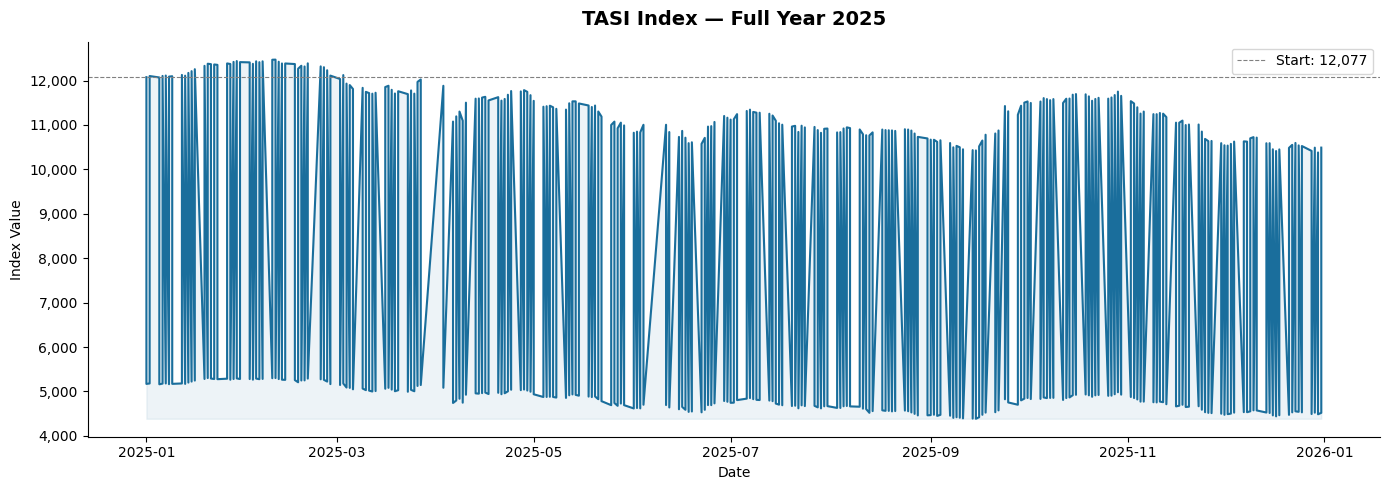

In [75]:
tasi = df_index[df_index['Index'].str.contains('TASI', case=False, na=False)].copy()
tasi = tasi.sort_values('Date')

tasi_start = tasi.iloc[0]['Close']
tasi_end   = tasi.iloc[-1]['Close']
tasi_max   = tasi['Close'].max()
tasi_min   = tasi['Close'].min()
tasi_change = ((tasi_end - tasi_start) / tasi_start) * 100

print(f'TASI at start of 2025 : {tasi_start:,.2f}')
print(f'TASI at end of 2025   : {tasi_end:,.2f}')
print(f'Year high             : {tasi_max:,.2f}')
print(f'Year low              : {tasi_min:,.2f}')
print(f'Annual change         : {tasi_change:.1f}%')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tasi['Date'], tasi['Close'], color='#1A6E9C', linewidth=1.5)
ax.fill_between(tasi['Date'], tasi['Close'], tasi['Close'].min(), alpha=0.08, color='#1A6E9C')
ax.set_title('TASI Index — Full Year 2025', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.axhline(tasi_start, color='gray', linestyle='--', linewidth=0.8, label=f'Start: {tasi_start:,.0f}')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../images/q1_tasi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The TASI opened 2025 at 12,077 and closed at 10,491 — a decline of **-13.1%** over the year. The index reached its year high early in Q1, then entered a broad downtrend through Q2–Q3, before partially recovering in Q4. This signals a bearish year overall for the Saudi market.

### Q2: Which sectors generated the most trading value (liquidity leaders)?

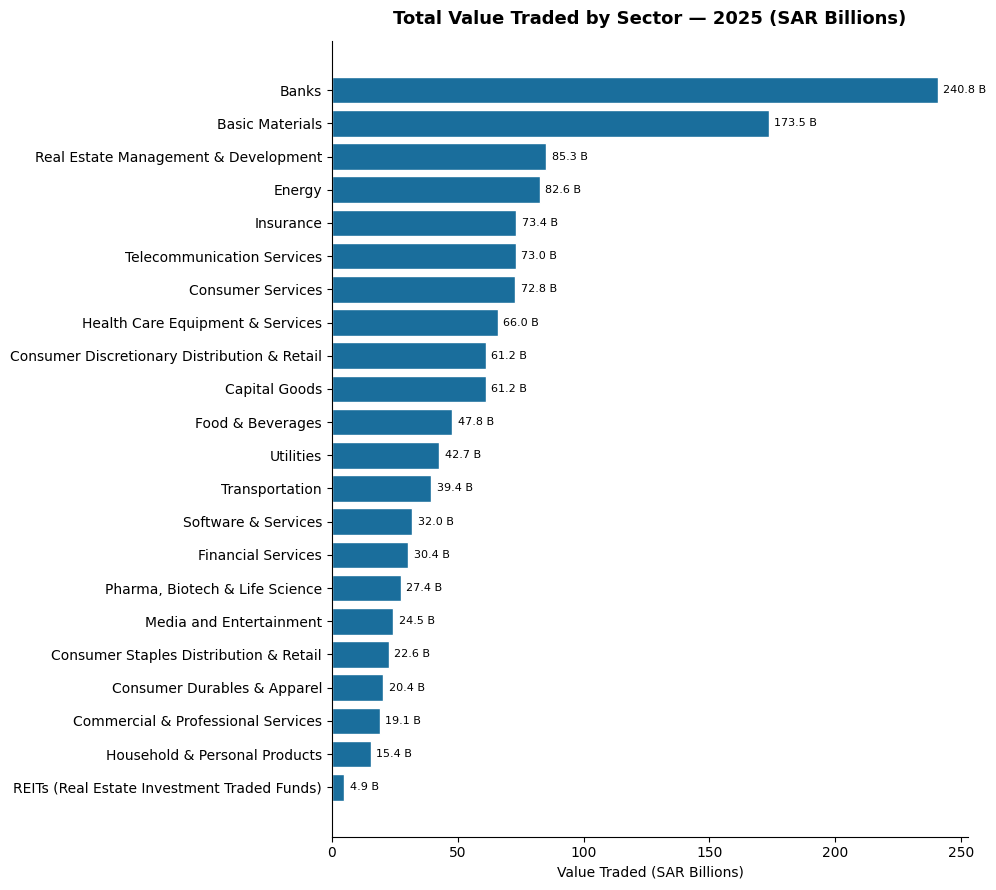


Top 5 most liquid sectors:
                                      SAR Billions
Sector                                            
Banks                                       240.76
Basic Materials                             173.54
Real Estate Management & Development         85.28
Energy                                       82.62
Insurance                                    73.38


In [76]:
sector_val = df_sector.groupby('Sector')['Value Traded (SAR)'].sum().sort_values(ascending=True)
sector_val_b = sector_val / 1e9  # convert to billions

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(sector_val_b.index, sector_val_b.values, color='#1A6E9C', edgecolor='white')
ax.bar_label(bars, fmt='%.1f B', padding=4, fontsize=8)
ax.set_title('Total Value Traded by Sector — 2025 (SAR Billions)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Value Traded (SAR Billions)')
sns.despine()
plt.tight_layout()
plt.savefig('../images/q2_sector_liquidity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most liquid sectors:')
print(sector_val_b.sort_values(ascending=False).head().to_frame('SAR Billions'))

**Interpretation:** The **Banks** sector dominated market liquidity with SAR 240.8B in total value traded — more than the next two sectors combined. **Basic Materials** and **Real Estate** followed. REITs had the lowest liquidity, suggesting limited retail participation in that segment.

### Q3: Which sectors had the best and worst price performance in 2025?

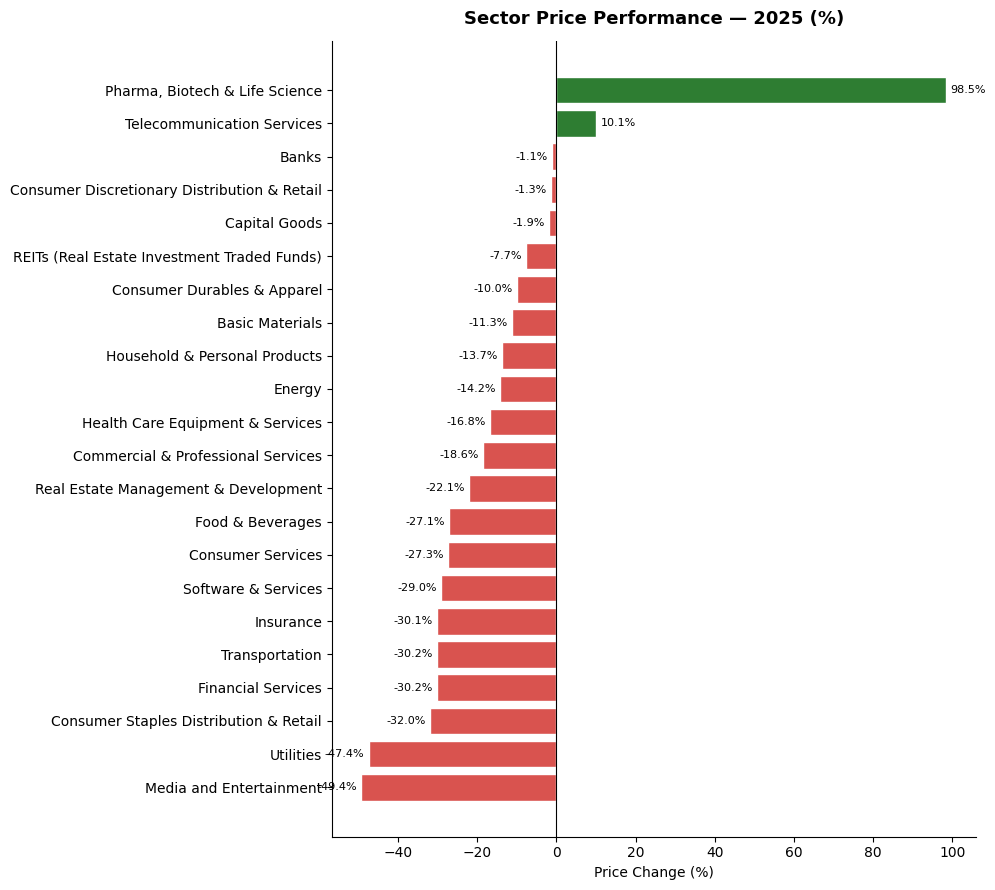

In [77]:
sector_perf = df_sector.groupby('Sector').apply(
    lambda x: ((x.sort_values('Date').iloc[-1]['Close'] - x.sort_values('Date').iloc[0]['Close'])
               / x.sort_values('Date').iloc[0]['Close']) * 100
).sort_values()

colors = ['#d9534f' if v < 0 else '#2e7d32' for v in sector_perf.values]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(sector_perf.index, sector_perf.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_title('Sector Price Performance — 2025 (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Price Change (%)')
sns.despine()
plt.tight_layout()
plt.savefig('../images/q3_sector_performance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Only **2 out of 22 sectors** posted positive returns in 2025. **Pharma, Biotech & Life Science** was the standout winner with +98.5% — largely driven by specific stock rallies. **Telecom** gained +10.1%. At the other end, **Media & Entertainment** (-49.4%) and **Utilities** (-47.4%) were the worst performers. The broad decline confirms the bearish TASI trend seen in Q1.

### Q4: How does volatility differ across Large, Mid, and Small Cap stocks?

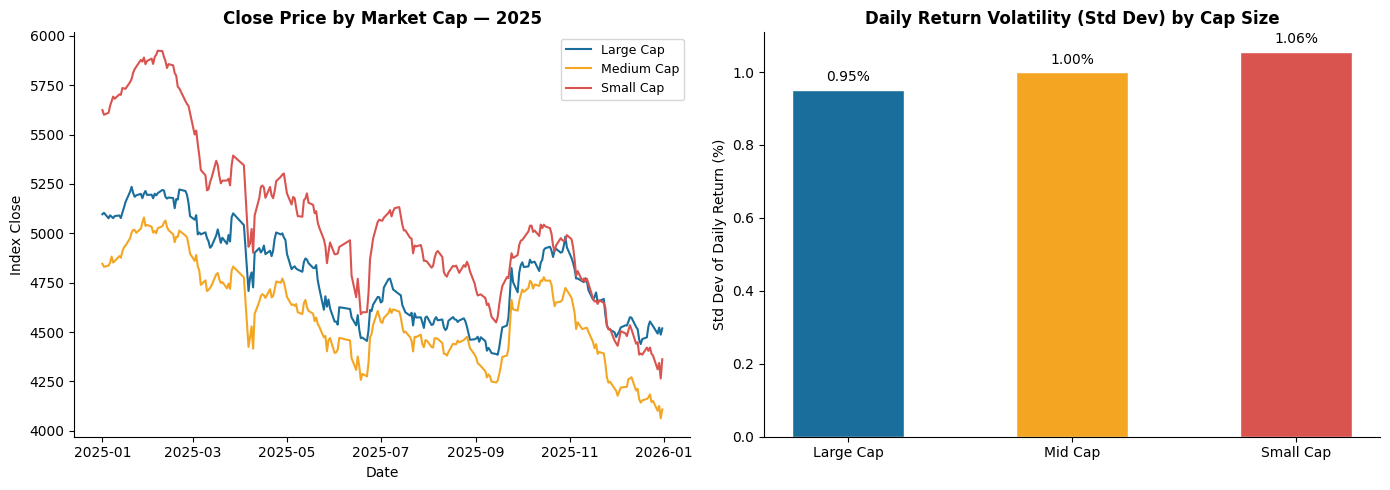


Volatility (Std Dev of Daily Returns):
  Large Cap: 0.95%
  Mid Cap: 1.00%
  Small Cap: 1.06%


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price trend by size
size_order = ['Tadawul Large Cap Index', 'Tadawul Medium Cap Index', 'Tadawul Small Cap Index']
palette = {'Tadawul Large Cap Index': '#1A6E9C', 'Tadawul Medium Cap Index': '#F4A623', 'Tadawul Small Cap Index': '#d9534f'}

for size in size_order:
    subset = df_size[df_size['Size'] == size].sort_values('Date')
    axes[0].plot(subset['Date'], subset['Close'], label=size.replace('Tadawul ', '').replace(' Index', ''), 
                 color=palette[size], linewidth=1.5)

axes[0].set_title('Close Price by Market Cap — 2025', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Index Close')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# Volatility bar chart
vol = df_size.groupby('Size')['Daily_Return_Pct'].std().reindex(size_order)
short_labels = ['Large Cap', 'Mid Cap', 'Small Cap']
bar_colors = [palette[s] for s in size_order]
bars = axes[1].bar(short_labels, vol.values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].bar_label(bars, fmt='%.2f%%', padding=4, fontsize=10)
axes[1].set_title('Daily Return Volatility (Std Dev) by Cap Size', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std Dev of Daily Return (%)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../images/q4_size_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nVolatility (Std Dev of Daily Returns):')
for s, v in zip(short_labels, vol.values):
    print(f'  {s}: {v:.2f}%')

**Interpretation:** **Small Cap** stocks were the most volatile with the highest standard deviation of daily returns — typical behavior since smaller companies are more sensitive to news and have lower liquidity. **Large Cap** and **Mid Cap** showed more similar, moderate volatility levels, reflecting the stability of established companies.

### Q5: Which months had the highest and lowest market activity?

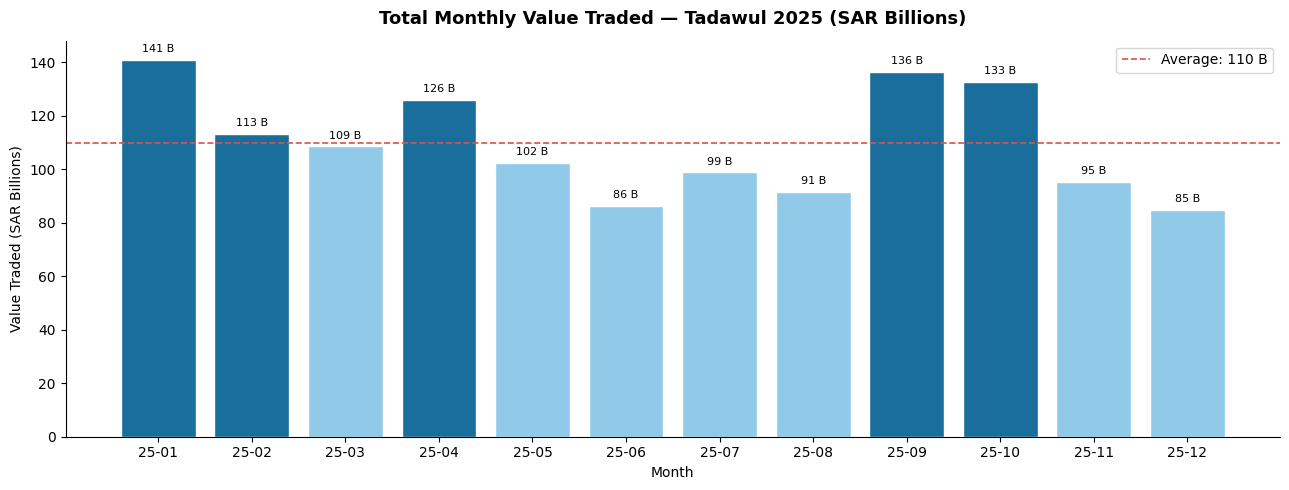

Most active month : 2025-01 — SAR 140.9B
Least active month: 2025-12 — SAR 84.9B


In [79]:
monthly = df_sector.groupby('Month')['Value Traded (SAR)'].sum().sort_index()
monthly_b = monthly / 1e9

month_labels = [m[-5:] for m in monthly_b.index]  # show MM format
bar_colors = ['#1A6E9C' if v >= monthly_b.mean() else '#90CAE8' for v in monthly_b.values]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(month_labels, monthly_b.values, color=bar_colors, edgecolor='white')
ax.bar_label(bars, fmt='%.0f B', padding=4, fontsize=8)
ax.axhline(monthly_b.mean(), color='#d9534f', linestyle='--', linewidth=1.2, label=f'Average: {monthly_b.mean():.0f} B')
ax.set_title('Total Monthly Value Traded — Tadawul 2025 (SAR Billions)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Value Traded (SAR Billions)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../images/q5_monthly_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Most active month : {monthly_b.idxmax()} — SAR {monthly_b.max():.1f}B')
print(f'Least active month: {monthly_b.idxmin()} — SAR {monthly_b.min():.1f}B')

**Interpretation:** **January 2025** was the most active month, likely driven by portfolio rebalancing at the start of the year and optimism at market open. Activity dipped notably mid-year, possibly due to summer seasonality and Ramadan. The market showed renewed activity spikes in Q3–Q4.

### Q6: Which sectors had the highest number of trades (retail investor activity)?

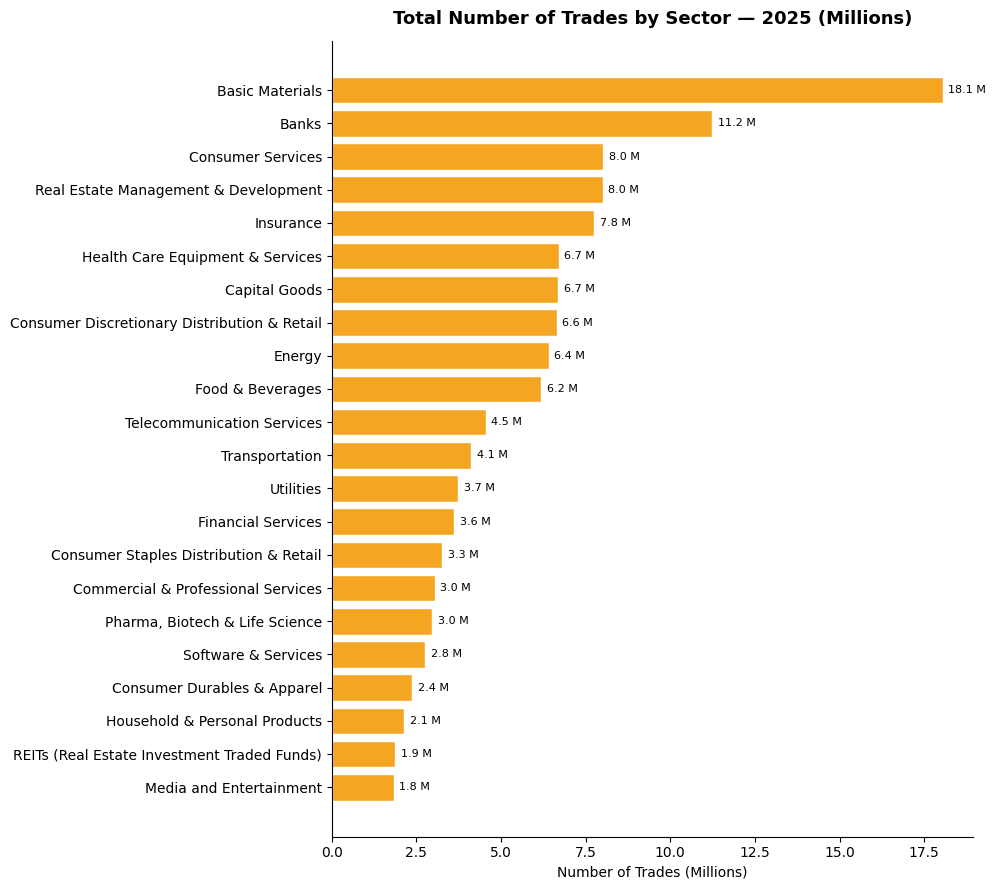

Top 5 sectors by trade count (retail activity):
                                     Trades
Sector                                     
Basic Materials                       18.1M
Banks                                 11.2M
Consumer Services                      8.0M
Real Estate Management & Development   8.0M
Insurance                              7.8M


In [80]:
sector_trades = df_sector.groupby('Sector')['Number of Trades'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(sector_trades.index, sector_trades.values / 1e6, color='#F4A623', edgecolor='white')
ax.bar_label(bars, fmt='%.1f M', padding=4, fontsize=8)
ax.set_title('Total Number of Trades by Sector — 2025 (Millions)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Trades (Millions)')
sns.despine()
plt.tight_layout()
plt.savefig('../images/q6_sector_trades.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 sectors by trade count (retail activity):')
print(sector_trades.sort_values(ascending=False).head().apply(lambda x: f'{x/1e6:.1f}M').to_frame('Trades'))

**Interpretation:** **Basic Materials** had the highest number of individual trades despite not being the top sector by value — this suggests high retail participation with smaller average transaction sizes. **Banks** rank second in both value traded and trade count, showing strong institutional and retail interest.

### Q7: Is there a correlation between trading volume and price performance by sector?

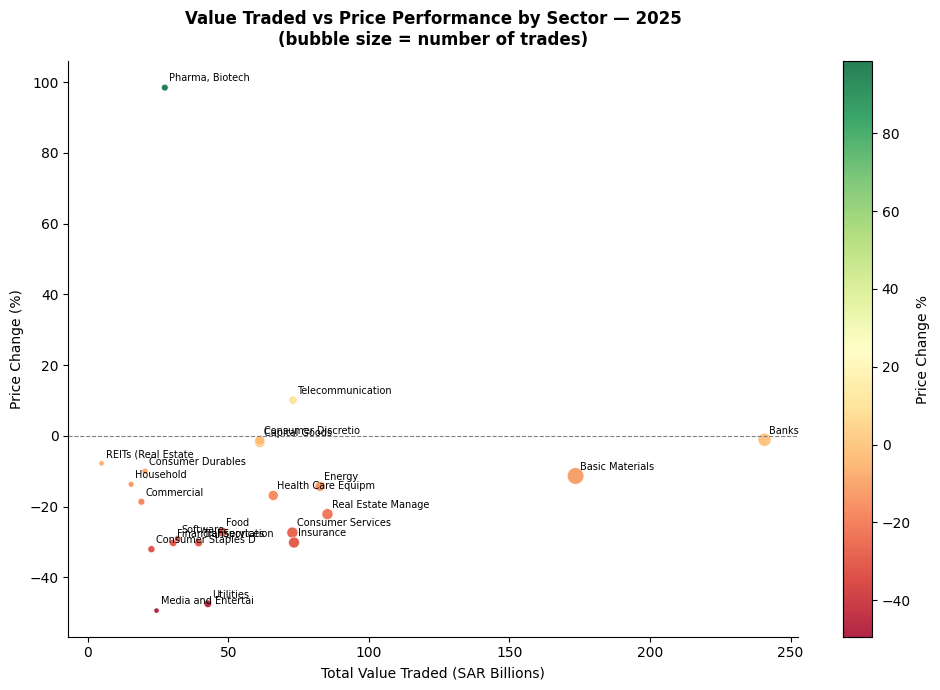

Correlation between Value Traded and Price Change: 0.068


In [81]:
sector_summary = df_sector.groupby('Sector').apply(lambda x: pd.Series({
    'Value_Traded_B': x['Value Traded (SAR)'].sum() / 1e9,
    'Total_Trades_M': x['Number of Trades'].sum() / 1e6,
    'Price_Change_Pct': ((x.sort_values('Date').iloc[-1]['Close'] - x.sort_values('Date').iloc[0]['Close'])
                         / x.sort_values('Date').iloc[0]['Close']) * 100
})).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    sector_summary['Value_Traded_B'],
    sector_summary['Price_Change_Pct'],
    s=sector_summary['Total_Trades_M'] * 8,
    c=sector_summary['Price_Change_Pct'],
    cmap='RdYlGn', alpha=0.85, edgecolors='white', linewidths=0.5
)

for _, row in sector_summary.iterrows():
    short = row['Sector'].split('&')[0].strip()[:18]
    ax.annotate(short, (row['Value_Traded_B'], row['Price_Change_Pct']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Value Traded vs Price Performance by Sector — 2025\n(bubble size = number of trades)', 
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Total Value Traded (SAR Billions)')
ax.set_ylabel('Price Change (%)')
plt.colorbar(scatter, ax=ax, label='Price Change %')
sns.despine()
plt.tight_layout()
plt.savefig('../images/q7_volume_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

corr = sector_summary['Value_Traded_B'].corr(sector_summary['Price_Change_Pct'])
print(f'Correlation between Value Traded and Price Change: {corr:.3f}')

**Interpretation:** The scatter plot reveals **no strong linear correlation** between trading volume and price performance. High-volume sectors like Banks and Basic Materials still experienced price declines, while Pharma had exceptional returns on relatively lower volume. This suggests that in a broad market downturn, even heavily traded sectors are not immune to price pressure.

---
## Phase 5 — Summary & Recommendations

### Key Findings

| # | Question | Finding |
|---|----------|---------|
| 1 | TASI trend | Declined **-13.1%** in 2025, from 12,077 to 10,491 |
| 2 | Most liquid sector | **Banks** — SAR 240.8B in value traded |
| 3 | Best performer | **Pharma** +98.5%; Worst: **Media & Entertainment** -49.4% |
| 4 | Volatility by size | **Small Cap** most volatile; Large & Mid Cap more stable |
| 5 | Most active month | **January 2025** — highest market activity |
| 6 | Most retail activity | **Basic Materials** — highest trade count |
| 7 | Volume vs performance | **Weak correlation** — high volume did not protect against price declines |

### Recommendations

1. **Defensive positioning**: Given the broad market decline, investors may consider rotating into sectors that showed resilience — Pharma and Telecom — in similar market conditions.

2. **Risk-adjusted allocation**: Small Cap stocks showed significantly higher volatility. Investors with lower risk tolerance should maintain a Large Cap tilt.

3. **Liquidity awareness**: The Banking sector dominates market liquidity. Monitoring banking sector health is a reliable proxy for overall market sentiment.

4. **Timing of activity**: January and early Q2 showed the highest trading activity — potentially driven by earnings season. Traders may find better execution during high-liquidity months.

5. **Volume ≠ protection**: High trading volume in a sector does not shield it from price decline in a bear market, as shown by Basic Materials and Real Estate. Fundamental analysis remains essential.

---
## Phase 6 — Export Final Data for Tableau

In [82]:
# Sector summary table
sector_summary_full = df_sector.groupby('Sector').apply(lambda x: pd.Series({
    'Total_Value_Traded_SAR': x['Value Traded (SAR)'].sum(),
    'Total_Trades': x['Number of Trades'].sum(),
    'Start_Close': x.sort_values('Date').iloc[0]['Close'],
    'End_Close': x.sort_values('Date').iloc[-1]['Close'],
    'Price_Change_Pct': ((x.sort_values('Date').iloc[-1]['Close'] - x.sort_values('Date').iloc[0]['Close'])
                         / x.sort_values('Date').iloc[0]['Close']) * 100,
    'Volatility_Std': x['Close'].std(),
    'Avg_Daily_Trades': x['Number of Trades'].mean()
})).reset_index()

sector_summary_full.to_csv('../data/tableau_sector_summary.csv', index=False)
df_sector.to_csv('../data/tableau_sector_daily.csv', index=False)
df_index.to_csv('../data/tableau_index_daily.csv', index=False)
df_size.to_csv('../data/tableau_size_daily.csv', index=False)

print('All Tableau-ready CSV files exported to /data folder:')
print('   - tableau_sector_summary.csv  (one row per sector)')
print('   - tableau_sector_daily.csv    (daily sector data)')
print('   - tableau_index_daily.csv     (TASI index daily)')
print('   - tableau_size_daily.csv      (Large/Mid/Small Cap daily)')

All Tableau-ready CSV files exported to /data folder:
   - tableau_sector_summary.csv  (one row per sector)
   - tableau_sector_daily.csv    (daily sector data)
   - tableau_index_daily.csv     (TASI index daily)
   - tableau_size_daily.csv      (Large/Mid/Small Cap daily)
